## (0) Settings and Functions

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    KFold, RepeatedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import make_scorer, hamming_loss

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings(
    "ignore",
    category=UndefinedMetricWarning
)

In [15]:
df = pd.read_csv("../../data/treated/go_emotions_treated.csv")

print(df.shape)
df.head(3)

(54234, 41)


,id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,UNCLEAN_TEXT_PT,BASE_TEXT_PT,TEXT_NO_STOP_PT,TEXT_LEMMA_PT,CLEAN_TEXT_PT,UNCLEAN_TEXT_EN,BASE_TEXT_EN,TEXT_NO_STOP_EN,TEXT_LEMMA_EN,CLEAN_TEXT_EN
0,eczazk6,0,0,0,0,1,0,0,0,0,...,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,tao rapido nome carregara seriamente uptown ce...,tao rapido quanto nome carregar seriamente upt...,tao rapido nome carregar seriamente uptown cen...,Fast as [NAME] will carry me. Seriously uptown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...
1,eczb07q,0,0,0,0,0,0,0,0,0,...,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,voce estragou tocaram voce violino,voce estragar isso eles tocar voce como violino,voce estragar tocar voce violino,You blew it. They played you like a fiddle.,you blew they played you like fiddle,you blew they played you like fiddle,you blew they played you like fiddle,you blew they played you like fiddle
2,eczb4bm,0,0,0,0,0,0,0,0,0,...,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,nao super bowls name prepare-se temporada vito...,nao mais super bowl para name preparar se para...,nao super bowl name preparar se temporada vito...,TL;DR No more Superbowls for [NAME]. Get ready...,more superbowls for name get ready for another...,more superbowls name get ready another winning...,more superbowls ser name get ready ser another...,more superbowls name get ready another winning...


In [16]:
def evaluate_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    hamming_scorer = make_scorer(
        hamming_loss,
        greater_is_better=False
    )

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
        'f1_micro': 'f1_micro',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'hamming_loss': hamming_scorer
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_macro']
    recall_scores  = results['test_recall_macro']
    f1_macro_scores = results['test_f1_macro']
    f1_weighted_scores = results['test_f1_weighted']
    f1_micro_scores = results['test_f1_micro']
    hamming_scores = results['test_hamming_loss']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_macro": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_macro":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_macro":   (f1_macro_scores.mean(),   f1_macro_scores.std(),   f1_macro_scores),
        "F1_weighted":   (f1_weighted_scores.mean(),   f1_weighted_scores.std(),   f1_weighted_scores),
        "F1_micro":   (f1_micro_scores.mean(),   f1_micro_scores.std(),   f1_micro_scores),
        "Hamming_loss":   (-hamming_scores.mean(),   hamming_scores.std(),   hamming_scores),
    }

def plot_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_macro'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=KFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    if not hasattr(model, "feature_importances_"):
        raise ValueError("Model does not expose feature_importances_")
    
    importances = model.feature_importances_

    if importances.ndim == 2:
        importances = importances.mean(axis=0)

    idx_sorted = np.argsort(importances)[::-1][:k]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(k), importances[idx_sorted][::-1])
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances (avg) - {model_name}")
    plt.xlabel("Mean Importance across labels")
    plt.tight_layout()
    plt.show()

## (1) Predict TEXT_NO_STOP_PT

In [17]:
df['TEXT_NO_STOP_PT'] = (
    df['TEXT_NO_STOP_PT']
    .fillna("")
    .astype(str)
)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

X_text = df['TEXT_NO_STOP_PT']
y = df[emotion_cols].values

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(37963,) (8135,) (8136,)



Running model: LogisticRegression


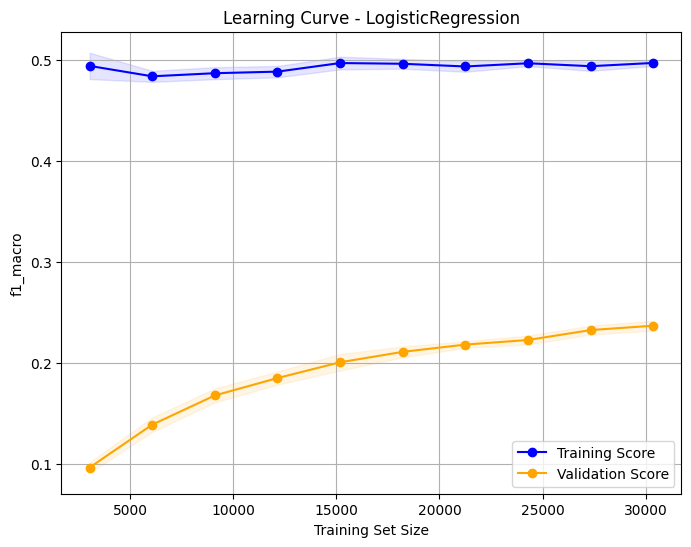


Running model: RidgeClassifier


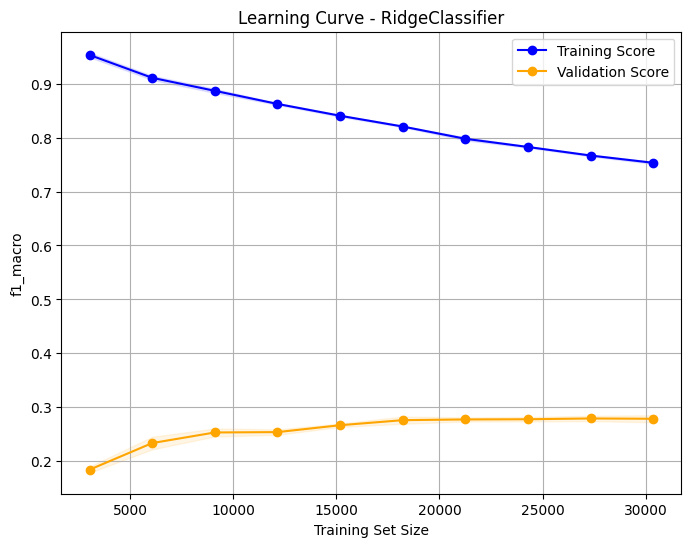


Running model: LinearSVC


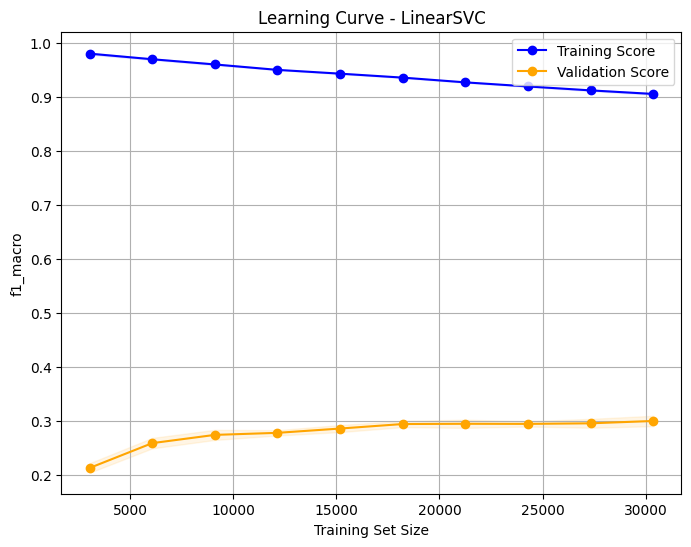


Running model: RandomForest


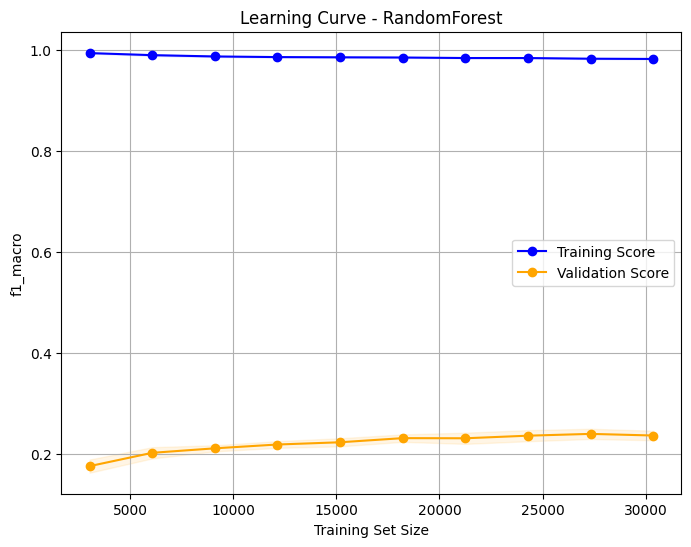


Running model: XGBClassifier


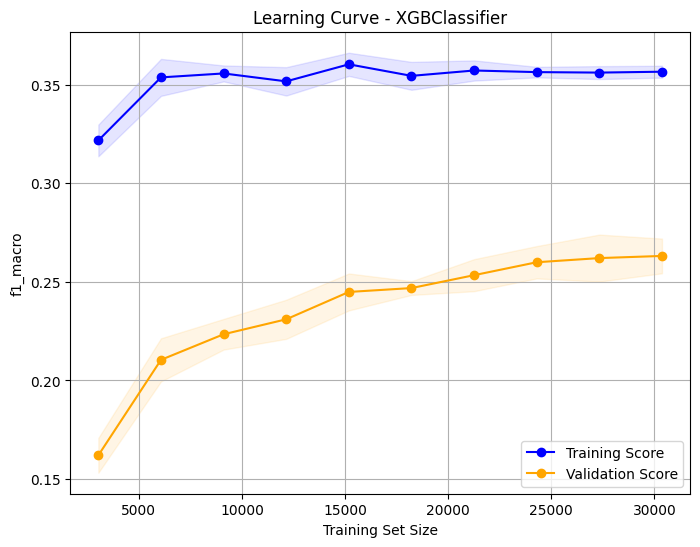

Best model: LinearSVC


In [18]:
models_for_testing = {
    "LogisticRegression": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": OneVsRestClassifier(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            verbosity=0
    ))
}

results = []

def run_predictions(name, model, X_text_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    pipe = Pipeline([
        ("bow", CountVectorizer()),
        ("model", model)
    ])

    cv_res = evaluate_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

    plot_learning_curve(clone(pipe), X_text_train, y_train, model_name=name, cv=5, scoring="f1_macro")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],

        "CV_F1_micro_mean":  cv_res["F1_micro"][0],
        "CV_F1_micro_std":   cv_res["F1_micro"][1],
        "CV_F1_micro_all":   cv_res["F1_micro"][2],

        "CV_Hamming_loss_mean":  cv_res["Hamming_loss"][0],
        "CV_Hamming_loss_std":   cv_res["Hamming_loss"][1],
        "CV_Hamming_loss_all":   cv_res["Hamming_loss"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_text_train, y_train)

df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

In [19]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro", "Hamming_loss"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro", "Hamming_loss"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/preprocess/preprocess_05_GoEmotions_BoW_TEXT_NO_STOP_PT.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,F1_micro,Hamming_loss
LogisticRegression,0.2295 ± 0.0044,0.5339 ± 0.0273,0.1711 ± 0.0052,0.2361 ± 0.0082,0.3273 ± 0.0047,0.3603 ± 0.0043,0.0383 ± 0.0003
RidgeClassifier,0.2272 ± 0.0036,0.4926 ± 0.0199,0.2179 ± 0.0062,0.2802 ± 0.0068,0.3371 ± 0.0045,0.3682 ± 0.0042,0.0397 ± 0.0003
LinearSVC,0.237 ± 0.0039,0.3931 ± 0.0157,0.251 ± 0.0072,0.2989 ± 0.0084,0.3609 ± 0.005,0.3774 ± 0.0044,0.0442 ± 0.0004
RandomForest,0.2348 ± 0.0047,0.4706 ± 0.0233,0.1716 ± 0.005,0.2321 ± 0.0068,0.3148 ± 0.0045,0.3434 ± 0.0048,0.0401 ± 0.0003
XGBClassifier,0.1473 ± 0.0035,0.6073 ± 0.0189,0.1912 ± 0.007,0.2613 ± 0.009,0.2442 ± 0.005,0.2809 ± 0.0051,0.038 ± 0.0003


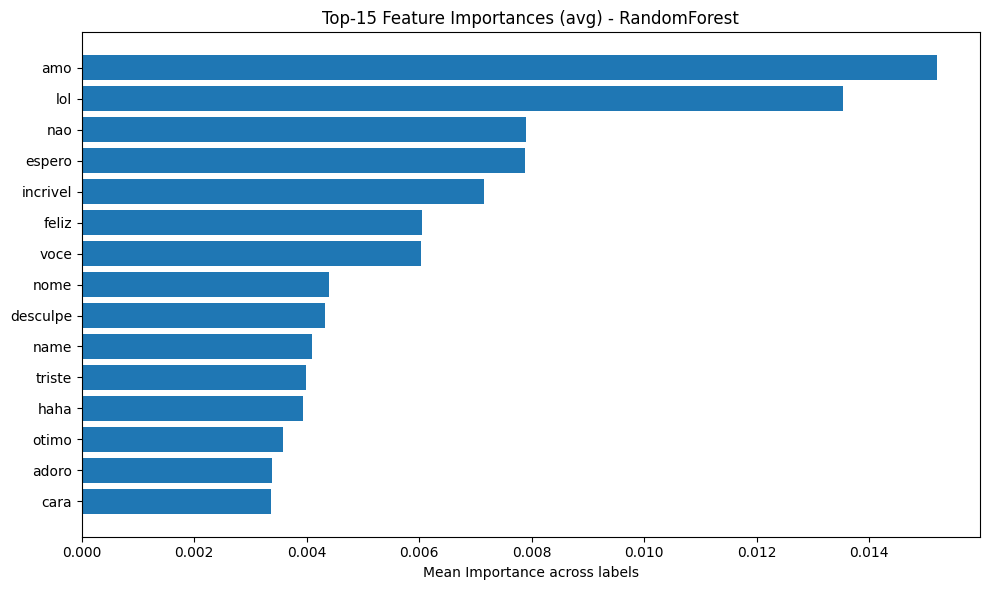

In [20]:
pipe_rf = Pipeline([
    ("bow", CountVectorizer()),
    ("model", RandomForestClassifier(random_state=42))
])
pipe_rf.fit(X_text_train, y_train)

feature_names = pipe_rf["bow"].get_feature_names_out()
plot_feature_importance_top_k(pipe_rf["model"], feature_names, k=15, model_name="RandomForest")

In [21]:
rows = []

for _, row in df_results.iterrows():
    model = row["Model"]
    for score in row["CV_F1_macro_all"]:
        rows.append({
            "Model": model,
            "F1_macro": score
        })

df_long = pd.DataFrame(rows)

df_pivot = df_long.pivot_table(
    index=df_long.groupby("Model").cumcount(),
    columns="Model",
    values="F1_macro"
)

stat, p_value = friedmanchisquare(
    *[df_pivot[col].values for col in df_pivot.columns]
)

print(f"Friedman chi2 = {stat:.4f}") # p >= 0.05 -> there is no overall statistical difference                    
print(f"p-value = {p_value:.6f}") # p < 0.05 -> at least one model is statistically different

alpha = 0.05
results_wilcoxon = []

models = df_pivot.columns.tolist()

for m1, m2 in itertools.combinations(models, 2):
    stat, p = wilcoxon(df_pivot[m1], df_pivot[m2])
    results_wilcoxon.append({
        "Model_1": m1,
        "Model_2": m2,
        "p_value": p,
    })

df_wilcoxon = pd.DataFrame(results_wilcoxon)

df_wilcoxon["p_corrected"] = multipletests(
    df_wilcoxon["p_value"],
    method="holm"
)[1]

df_wilcoxon["Significant"] = df_wilcoxon["p_corrected"] < alpha

df_wilcoxon.style.hide(axis="index")

Friedman chi2 = 114.3200
p-value = 0.000000


Model_1,Model_2,p_value,p_corrected,Significant
LinearSVC,LogisticRegression,0.000000,0.000000,True
LinearSVC,RandomForest,0.000000,0.000000,True
LinearSVC,RidgeClassifier,0.000000,0.000000,True
LinearSVC,XGBClassifier,0.000000,0.000000,True
LogisticRegression,RandomForest,0.015460,0.015460,True
LogisticRegression,RidgeClassifier,0.000000,0.000000,True
LogisticRegression,XGBClassifier,0.000000,0.000000,True
RandomForest,RidgeClassifier,0.000000,0.000000,True
RandomForest,XGBClassifier,0.000000,0.000000,True
RidgeClassifier,XGBClassifier,0.000000,0.000000,True


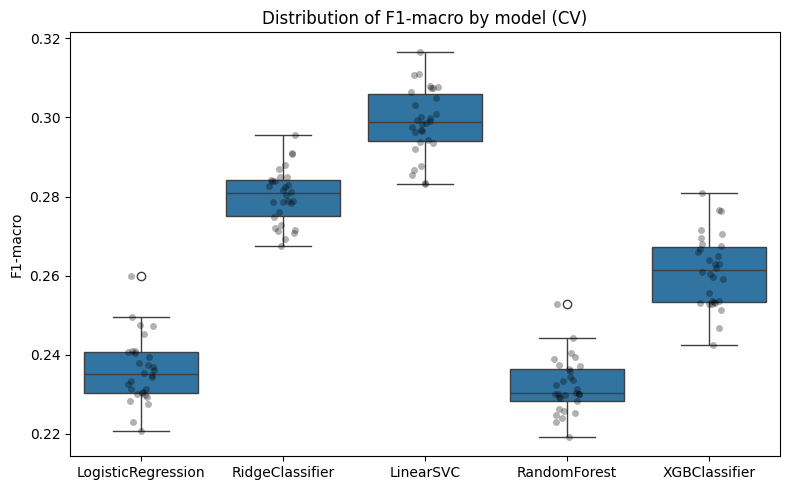

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x="Model",
    y="F1_macro"
)
sns.stripplot(
    data=df_long,
    x="Model",
    y="F1_macro",
    color="black",
    alpha=0.3
)

plt.title("Distribution of F1-macro by model (CV)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()

## (2) Predict with TEXT_LEMMA_PT

In [23]:
df['TEXT_LEMMA_PT'] = (
    df['TEXT_LEMMA_PT']
    .fillna("")
    .astype(str)
)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

X_text = df['TEXT_LEMMA_PT']
y = df[emotion_cols].values

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(37963,) (8135,) (8136,)



Running model: LogisticRegression


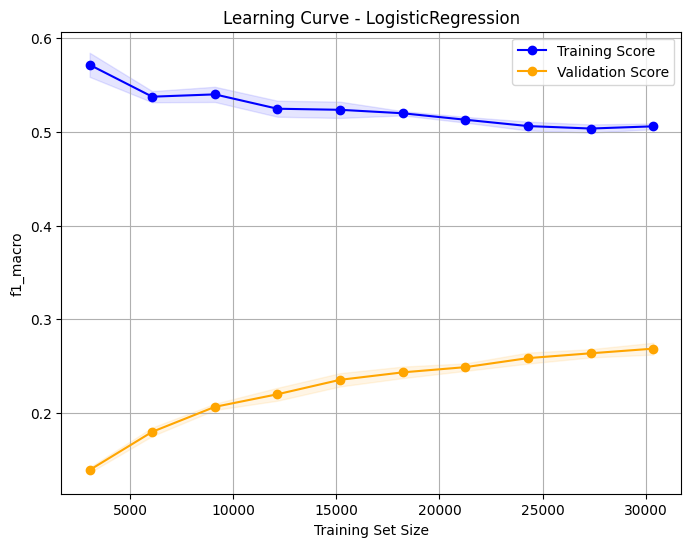


Running model: RidgeClassifier


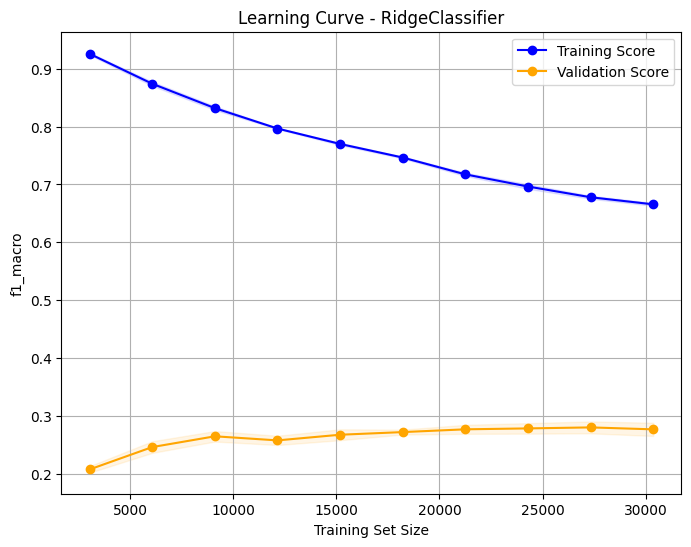


Running model: LinearSVC


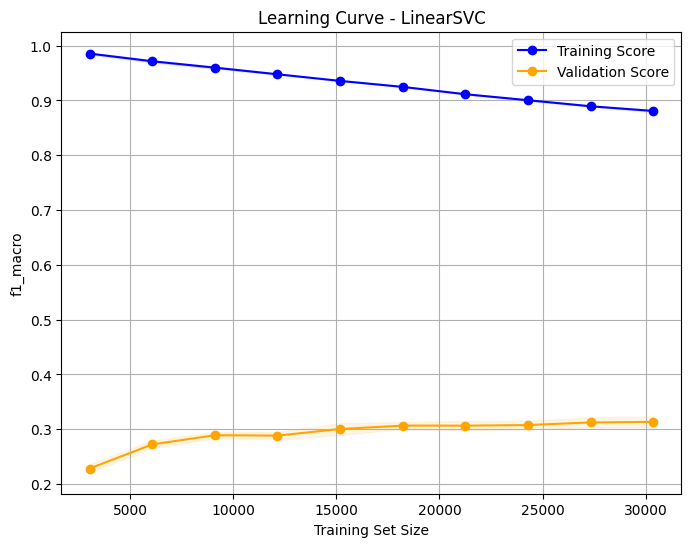


Running model: RandomForest


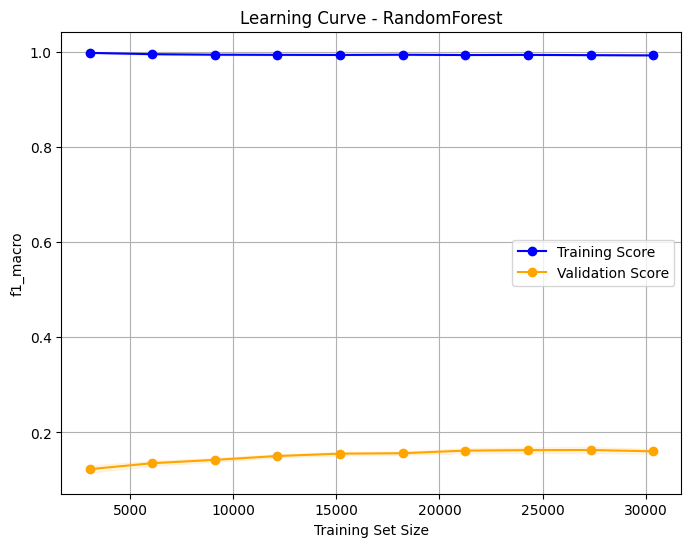


Running model: XGBClassifier


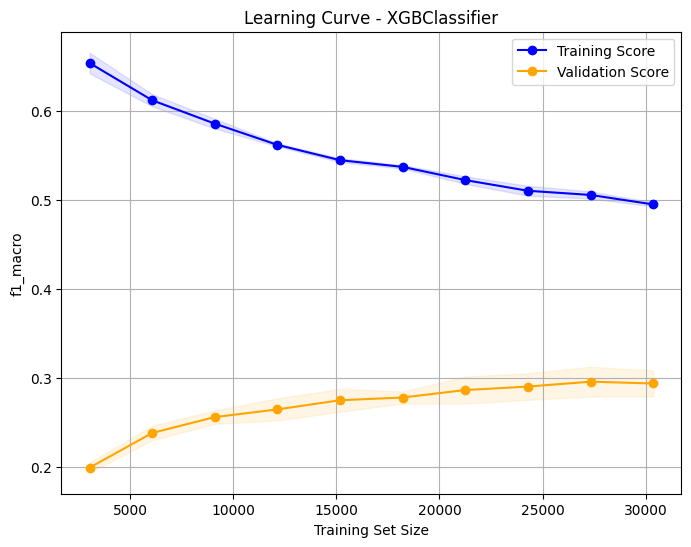

Best model: LinearSVC


In [24]:
models_for_testing = {
    "LogisticRegression": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": OneVsRestClassifier(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            verbosity=0
    ))
}

results = []

def run_predictions(name, model, X_text_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    pipe = Pipeline([
        ("bow", CountVectorizer()),
        ("model", model)
    ])

    cv_res = evaluate_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

    plot_learning_curve(clone(pipe), X_text_train, y_train, model_name=name, cv=5, scoring="f1_macro")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],

        "CV_F1_micro_mean":  cv_res["F1_micro"][0],
        "CV_F1_micro_std":   cv_res["F1_micro"][1],
        "CV_F1_micro_all":   cv_res["F1_micro"][2],

        "CV_Hamming_loss_mean":  cv_res["Hamming_loss"][0],
        "CV_Hamming_loss_std":   cv_res["Hamming_loss"][1],
        "CV_Hamming_loss_all":   cv_res["Hamming_loss"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_text_train, y_train)

df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

In [25]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro", "Hamming_loss"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro", "Hamming_loss"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/preprocess/preprocess_05_GoEmotions_BoW_TEXT_LEMMA_PT.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,F1_micro,Hamming_loss
LogisticRegression,0.2953 ± 0.0053,0.5161 ± 0.0233,0.2052 ± 0.0048,0.2678 ± 0.0068,0.3911 ± 0.0067,0.433 ± 0.0062,0.0362 ± 0.0004
RidgeClassifier,0.271 ± 0.0056,0.4829 ± 0.0209,0.2262 ± 0.0071,0.2807 ± 0.0072,0.3721 ± 0.0061,0.4162 ± 0.0059,0.0373 ± 0.0004
LinearSVC,0.2853 ± 0.006,0.392 ± 0.0139,0.2709 ± 0.0063,0.3136 ± 0.0075,0.4072 ± 0.0063,0.428 ± 0.0057,0.0418 ± 0.0004
RandomForest,0.2447 ± 0.0041,0.4711 ± 0.0237,0.1155 ± 0.0029,0.1595 ± 0.0044,0.3042 ± 0.0044,0.3573 ± 0.0046,0.0369 ± 0.0003
XGBClassifier,0.2397 ± 0.0112,0.5727 ± 0.0206,0.2246 ± 0.0072,0.2925 ± 0.0093,0.349 ± 0.0104,0.3888 ± 0.0107,0.036 ± 0.0004


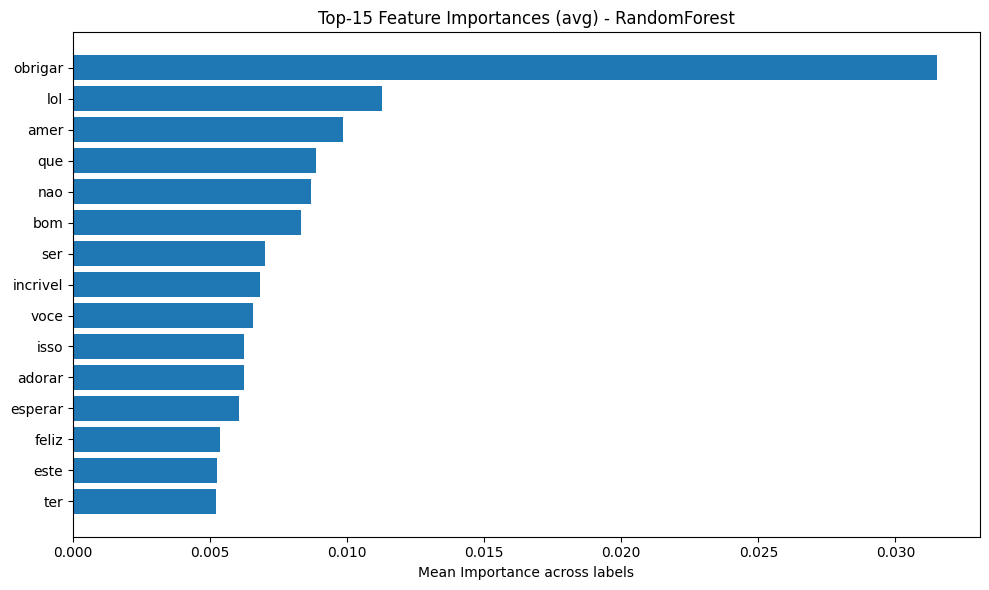

In [26]:
pipe_rf = Pipeline([
    ("bow", CountVectorizer()),
    ("model", RandomForestClassifier(random_state=42))
])
pipe_rf.fit(X_text_train, y_train)

feature_names = pipe_rf["bow"].get_feature_names_out()
plot_feature_importance_top_k(pipe_rf["model"], feature_names, k=15, model_name="RandomForest")

In [27]:
rows = []

for _, row in df_results.iterrows():
    model = row["Model"]
    for score in row["CV_F1_macro_all"]:
        rows.append({
            "Model": model,
            "F1_macro": score
        })

df_long = pd.DataFrame(rows)

df_pivot = df_long.pivot_table(
    index=df_long.groupby("Model").cumcount(),
    columns="Model",
    values="F1_macro"
)

stat, p_value = friedmanchisquare(
    *[df_pivot[col].values for col in df_pivot.columns]
)

print(f"Friedman chi2 = {stat:.4f}") # p >= 0.05 -> there is no overall statistical difference                    
print(f"p-value = {p_value:.6f}") # p < 0.05 -> at least one model is statistically different

alpha = 0.05
results_wilcoxon = []

models = df_pivot.columns.tolist()

for m1, m2 in itertools.combinations(models, 2):
    stat, p = wilcoxon(df_pivot[m1], df_pivot[m2])
    results_wilcoxon.append({
        "Model_1": m1,
        "Model_2": m2,
        "p_value": p,
    })

df_wilcoxon = pd.DataFrame(results_wilcoxon)

df_wilcoxon["p_corrected"] = multipletests(
    df_wilcoxon["p_value"],
    method="holm"
)[1]

df_wilcoxon["Significant"] = df_wilcoxon["p_corrected"] < alpha

df_wilcoxon.style.hide(axis="index")

Friedman chi2 = 117.7333
p-value = 0.000000


Model_1,Model_2,p_value,p_corrected,Significant
LinearSVC,LogisticRegression,0.000000,0.000000,True
LinearSVC,RandomForest,0.000000,0.000000,True
LinearSVC,RidgeClassifier,0.000000,0.000000,True
LinearSVC,XGBClassifier,0.000000,0.000000,True
LogisticRegression,RandomForest,0.000000,0.000000,True
LogisticRegression,RidgeClassifier,0.000000,0.000000,True
LogisticRegression,XGBClassifier,0.000000,0.000000,True
RandomForest,RidgeClassifier,0.000000,0.000000,True
RandomForest,XGBClassifier,0.000000,0.000000,True
RidgeClassifier,XGBClassifier,0.000000,0.000000,True


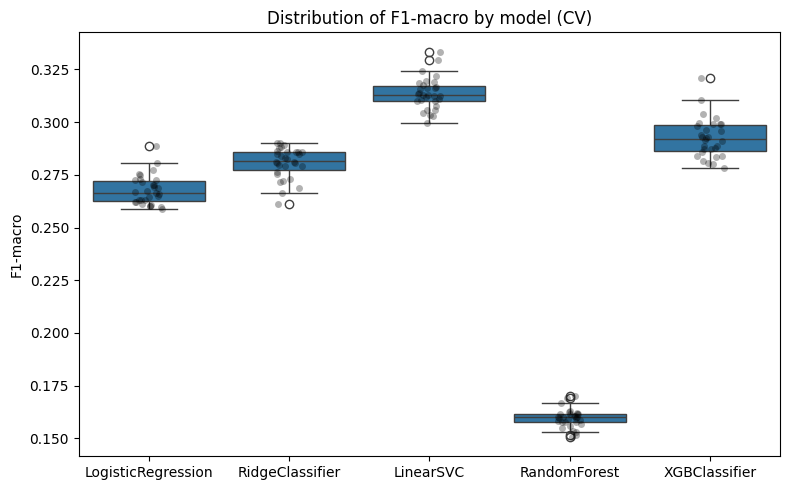

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x="Model",
    y="F1_macro"
)
sns.stripplot(
    data=df_long,
    x="Model",
    y="F1_macro",
    color="black",
    alpha=0.3
)

plt.title("Distribution of F1-macro by model (CV)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()

## (3) Predict with CLEAN_TEXT_PT

In [29]:
df['CLEAN_TEXT_PT'] = (
    df['CLEAN_TEXT_PT']
    .fillna("")
    .astype(str)
)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

X_text = df['CLEAN_TEXT_PT']
y = df[emotion_cols].values

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(37963,) (8135,) (8136,)



Running model: LogisticRegression


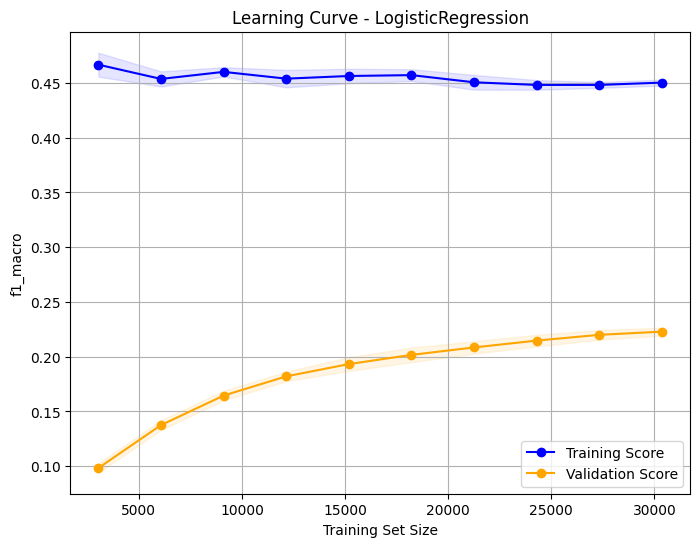


Running model: RidgeClassifier


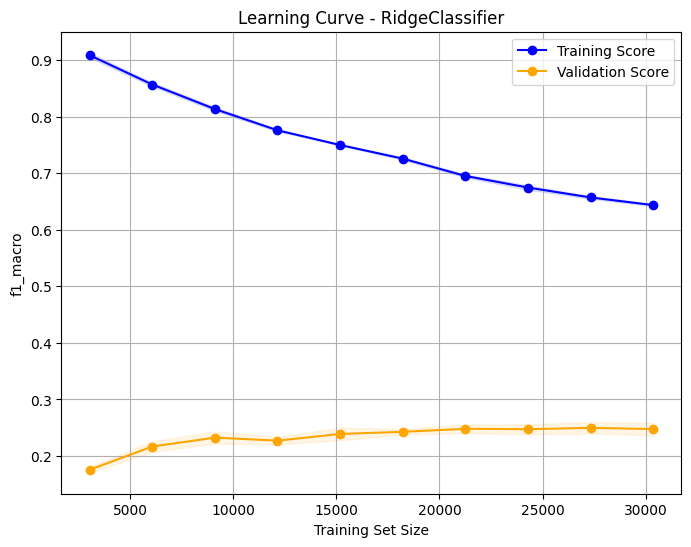


Running model: LinearSVC


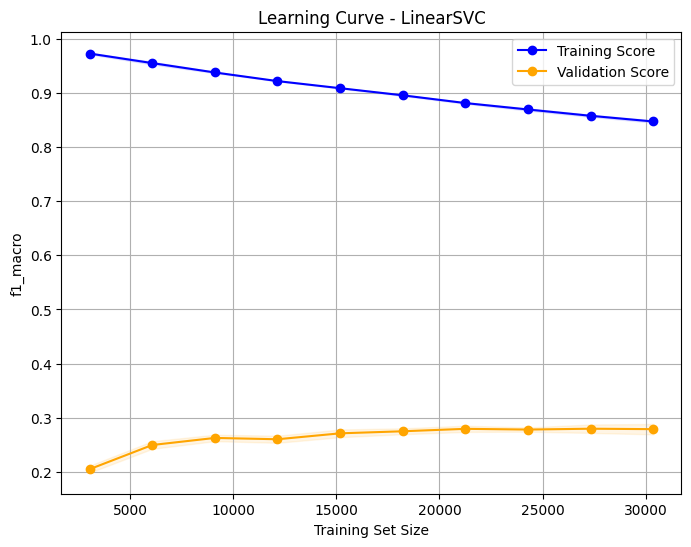


Running model: RandomForest


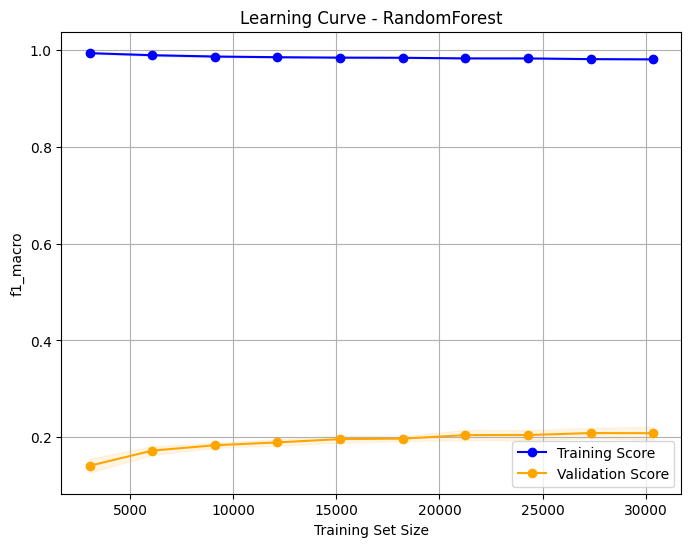


Running model: XGBClassifier


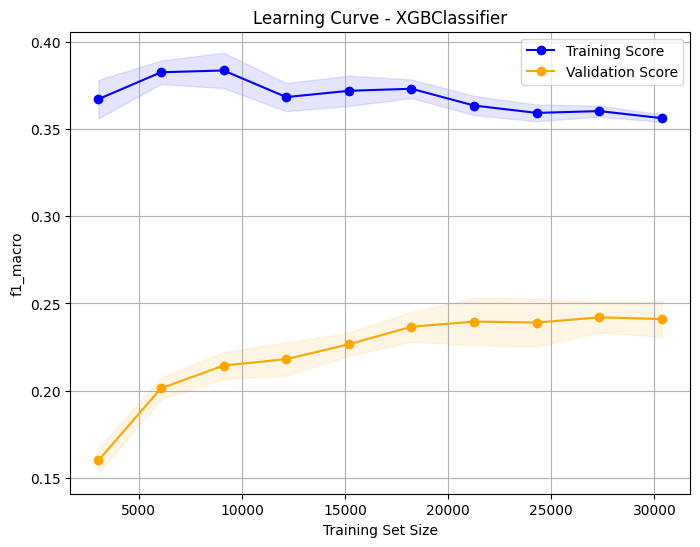

Best model: LinearSVC


In [30]:
models_for_testing = {
    "LogisticRegression": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": OneVsRestClassifier(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            verbosity=0
    ))
}

results = []

def run_predictions(name, model, X_text_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    pipe = Pipeline([
        ("bow", CountVectorizer()),
        ("model", model)
    ])

    cv_res = evaluate_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

    plot_learning_curve(clone(pipe), X_text_train, y_train, model_name=name, cv=5, scoring="f1_macro")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],

        "CV_F1_micro_mean":  cv_res["F1_micro"][0],
        "CV_F1_micro_std":   cv_res["F1_micro"][1],
        "CV_F1_micro_all":   cv_res["F1_micro"][2],

        "CV_Hamming_loss_mean":  cv_res["Hamming_loss"][0],
        "CV_Hamming_loss_std":   cv_res["Hamming_loss"][1],
        "CV_Hamming_loss_all":   cv_res["Hamming_loss"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_text_train, y_train)

df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

In [31]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro", "Hamming_loss"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro", "Hamming_loss"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/preprocess/preprocess_05_GoEmotions_BoW_CLEAN_TEXT_PT.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,F1_micro,Hamming_loss
LogisticRegression,0.2256 ± 0.0037,0.5066 ± 0.0274,0.1646 ± 0.0049,0.2259 ± 0.0074,0.3207 ± 0.0042,0.3544 ± 0.004,0.0387 ± 0.0003
RidgeClassifier,0.2164 ± 0.0043,0.4617 ± 0.0208,0.1964 ± 0.0072,0.2517 ± 0.0076,0.3174 ± 0.0055,0.3527 ± 0.0054,0.0397 ± 0.0004
LinearSVC,0.2262 ± 0.0047,0.3726 ± 0.012,0.2357 ± 0.0071,0.2818 ± 0.0077,0.3458 ± 0.0048,0.3636 ± 0.0043,0.0443 ± 0.0003
RandomForest,0.2175 ± 0.0048,0.4537 ± 0.0219,0.1506 ± 0.0054,0.206 ± 0.008,0.2942 ± 0.005,0.3244 ± 0.0054,0.0401 ± 0.0003
XGBClassifier,0.1461 ± 0.0046,0.5706 ± 0.0173,0.1802 ± 0.0071,0.2447 ± 0.0085,0.2402 ± 0.0058,0.2767 ± 0.0061,0.0384 ± 0.0003


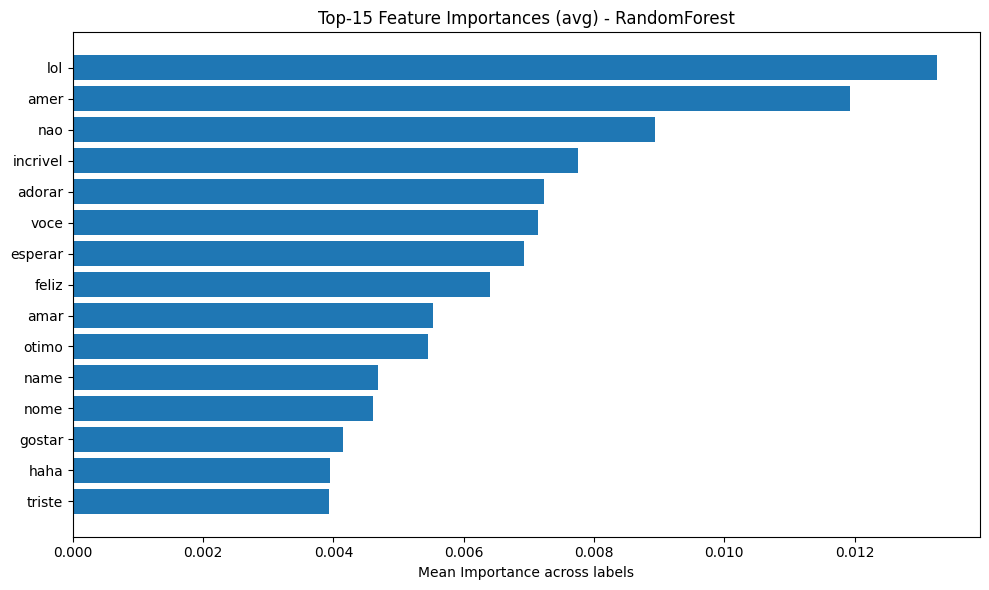

In [32]:
pipe_rf = Pipeline([
    ("bow", CountVectorizer()),
    ("model", RandomForestClassifier(random_state=42))
])
pipe_rf.fit(X_text_train, y_train)

feature_names = pipe_rf["bow"].get_feature_names_out()
plot_feature_importance_top_k(pipe_rf["model"], feature_names, k=15, model_name="RandomForest")

In [33]:
rows = []

for _, row in df_results.iterrows():
    model = row["Model"]
    for score in row["CV_F1_macro_all"]:
        rows.append({
            "Model": model,
            "F1_macro": score
        })

df_long = pd.DataFrame(rows)

df_pivot = df_long.pivot_table(
    index=df_long.groupby("Model").cumcount(),
    columns="Model",
    values="F1_macro"
)

stat, p_value = friedmanchisquare(
    *[df_pivot[col].values for col in df_pivot.columns]
)

print(f"Friedman chi2 = {stat:.4f}") # p >= 0.05 -> there is no overall statistical difference                    
print(f"p-value = {p_value:.6f}") # p < 0.05 -> at least one model is statistically different

alpha = 0.05
results_wilcoxon = []

models = df_pivot.columns.tolist()

for m1, m2 in itertools.combinations(models, 2):
    stat, p = wilcoxon(df_pivot[m1], df_pivot[m2])
    results_wilcoxon.append({
        "Model_1": m1,
        "Model_2": m2,
        "p_value": p,
    })

df_wilcoxon = pd.DataFrame(results_wilcoxon)

df_wilcoxon["p_corrected"] = multipletests(
    df_wilcoxon["p_value"],
    method="holm"
)[1]

df_wilcoxon["Significant"] = df_wilcoxon["p_corrected"] < alpha

df_wilcoxon.style.hide(axis="index")

Friedman chi2 = 115.5467
p-value = 0.000000


Model_1,Model_2,p_value,p_corrected,Significant
LinearSVC,LogisticRegression,0.000000,0.000000,True
LinearSVC,RandomForest,0.000000,0.000000,True
LinearSVC,RidgeClassifier,0.000000,0.000000,True
LinearSVC,XGBClassifier,0.000000,0.000000,True
LogisticRegression,RandomForest,0.000000,0.000000,True
LogisticRegression,RidgeClassifier,0.000000,0.000000,True
LogisticRegression,XGBClassifier,0.000000,0.000000,True
RandomForest,RidgeClassifier,0.000000,0.000000,True
RandomForest,XGBClassifier,0.000000,0.000000,True
RidgeClassifier,XGBClassifier,0.000027,0.000027,True


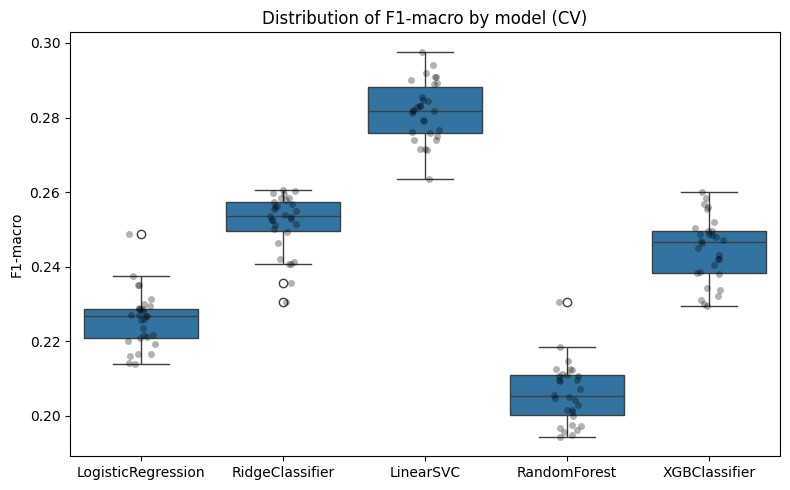

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x="Model",
    y="F1_macro"
)
sns.stripplot(
    data=df_long,
    x="Model",
    y="F1_macro",
    color="black",
    alpha=0.3
)

plt.title("Distribution of F1-macro by model (CV)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()